## 4. Apply ML Methods and Additional Hypothesis Tests

This section extends the statistical analysis with several hypothesis tests and one machine learning method. The goal is to examine whether poverty and ethnic composition are significantly associated with cardiovascular mortality, and then test whether these variables can predict county-level mortality rates.

In [1]:
import pandas as pd

pov = pd.read_csv("datasets/poverty2010.csv", skiprows=2)

pov.columns = pov.columns.str.strip().str.lower()

pov = pov[[
    "state fips",
    "county fips",
    "postal",
    "name",
    "poverty percent all ages"
]].copy()

pov["state fips"] = pd.to_numeric(pov["state fips"], errors="coerce")
pov["county fips"] = pd.to_numeric(pov["county fips"], errors="coerce")
pov["poverty percent all ages"] = pd.to_numeric(pov["poverty percent all ages"], errors="coerce")

pov = pov.dropna(subset=["state fips", "county fips", "poverty percent all ages"])

pov = pov[pov["county fips"] != 0].copy()

pov["state fips"] = pov["state fips"].astype(int).astype(str).str.zfill(2)
pov["county fips"] = pov["county fips"].astype(int).astype(str).str.zfill(3)
pov["fips"] = pov["state fips"] + pov["county fips"]

pov = pov[["fips", "postal", "name", "poverty percent all ages"]].copy()
pov.columns = ["fips", "state", "county", "poverty_rate"]

pov = pov[pov["county"].str.lower().str.strip() != "united states"].copy()

pov["county"] = pov["county"].astype(str).str.strip()
pov["state"] = pov["state"].astype(str).str.strip().str.upper()


pov.head()

import pandas as pd
import re

demo = pd.read_csv("datasets/demographics.csv")

demo.columns = demo.columns.str.strip().str.lower()

demo = demo[[
    "county",
    "state",
    "ethnicities.black alone",
    "ethnicities.white alone",
    "ethnicities.hispanic or latino"
]].copy()

demo.columns = ["county", "state", "black", "white", "hispanic"]

demo["black"] = pd.to_numeric(demo["black"], errors="coerce")
demo["white"] = pd.to_numeric(demo["white"], errors="coerce")
demo["hispanic"] = pd.to_numeric(demo["hispanic"], errors="coerce")

demo["county"] = demo["county"].astype(str).str.strip()
demo["state"] = demo["state"].astype(str).str.strip().str.upper()

def normalize_county(x):
    x = str(x).lower().strip()
    x = re.sub(r' county$', '', x)
    x = re.sub(r' parish$', '', x)
    x = re.sub(r' borough$', '', x)
    x = re.sub(r' census area$', '', x)
    x = re.sub(r' municipality$', '', x)
    x = re.sub(r' city and borough$', '', x)
    x = re.sub(r'[^a-z ]', '', x)
    x = re.sub(r'\s+', ' ', x)
    return x

demo["county_clean"] = demo["county"].apply(normalize_county)


demo.head()

import pandas as pd


mort = pd.read_csv("datasets/mortality.csv")

mort.columns = mort.columns.str.strip().str.lower()

mort = mort[[
    "fips",
    "category",
    "mortality rate, 2010*"
]].copy()

mort.columns = ["fips", "category", "mortality_rate"]


mort["fips"] = pd.to_numeric(mort["fips"], errors="coerce")
mort["mortality_rate"] = pd.to_numeric(mort["mortality_rate"], errors="coerce")

mort = mort.dropna(subset=["fips", "mortality_rate"])

mort["fips"] = mort["fips"].astype(int).astype(str).str.zfill(5)

mort["category"] = mort["category"].astype(str).str.strip()


mort = mort[mort["category"] == "Cardiovascular diseases"].copy()


mort = mort.set_index("fips")


mort.head()

import pandas as pd
import re

def normalize_county(x):
    x = str(x).lower().strip()
    x = re.sub(r' county$', '', x)
    x = re.sub(r' parish$', '', x)
    x = re.sub(r' borough$', '', x)
    x = re.sub(r' census area$', '', x)
    x = re.sub(r' municipality$', '', x)
    x = re.sub(r' city and borough$', '', x)
    x = re.sub(r'[^a-z ]', '', x)
    x = re.sub(r'\s+', ' ', x)
    return x


pov["county"] = pov["county"].astype(str).str.strip()
pov["state"] = pov["state"].astype(str).str.strip().str.upper()
pov["county_clean"] = pov["county"].apply(normalize_county)

demo["county"] = demo["county"].astype(str).str.strip()
demo["state"] = demo["state"].astype(str).str.strip().str.upper()
demo["county_clean"] = demo["county"].apply(normalize_county)


base = pd.merge(
    pov,
    demo,
    on=["state", "county_clean"],
    how="inner",
    suffixes=("_pov", "_demo")
)

base = base[[
    "fips",
    "state",
    "county_pov",
    "poverty_rate",
    "black",
    "white",
    "hispanic"
]].copy()

base.columns = [
    "fips",
    "state",
    "county",
    "poverty_rate",
    "black",
    "white",
    "hispanic"
]


data = pd.merge(
    base,
    mort,
    on="fips",
    how="inner"
)


data = data[[
    "fips",
    "state",
    "county",
    "poverty_rate",
    "black",
    "white",
    "hispanic",
    "mortality_rate"
]].copy()

pd.set_option("display.max_rows", 10)
pd.set_option("display.min_rows", 5)
pd.set_option("display.max_columns", None)

data


,fips,state,county,poverty_rate,black,white,hispanic,mortality_rate
0,01001,AL,Autauga County,11.9,20.1,76.3,3.0,316.82
1,01003,AL,Baldwin County,13.3,8.8,87.4,4.7,279.98
...,...,...,...,...,...,...,...,...
3128,56043,WY,Washakie County,12.1,0.6,94.5,14.2,224.13
3129,56045,WY,Weston County,9.9,0.7,93.2,4.1,214.31


### 4.1 Hypotheses

We evaluate four hypotheses using the merged county-level dataset:

1. **H1:** Poverty rate is positively associated with cardiovascular mortality rate.
2. **H2:** Counties with above-median poverty have higher cardiovascular mortality than counties with below-median poverty.
3. **H3:** The percentage of Black population is positively associated with cardiovascular mortality rate.
4. **H4:** The percentage of White population is negatively associated with cardiovascular mortality rate.

For correlation-based tests, the null hypothesis states that there is no association between the variables. For the group comparison, the null hypothesis states that the mean mortality rates of high-poverty and low-poverty counties are equal.

In [2]:
from scipy.stats import pearsonr, ttest_ind
import pandas as pd
import numpy as np

analysis_data = data[["poverty_rate", "black", "white", "hispanic", "mortality_rate"]].dropna().copy()

test_results = []

corr, p_value = pearsonr(analysis_data["poverty_rate"], analysis_data["mortality_rate"])
test_results.append({
    "Hypothesis": "H1: Poverty vs mortality",
    "Test": "Pearson correlation",
    "Statistic": corr,
    "P-value": p_value
})


poverty_median = analysis_data["poverty_rate"].median()
high_poverty = analysis_data.loc[analysis_data["poverty_rate"] >= poverty_median, "mortality_rate"]
low_poverty = analysis_data.loc[analysis_data["poverty_rate"] < poverty_median, "mortality_rate"]
t_stat, p_value = ttest_ind(high_poverty, low_poverty, equal_var=False)
test_results.append({
    "Hypothesis": "H2: High vs low poverty mortality",
    "Test": "Welch two-sample t-test",
    "Statistic": t_stat,
    "P-value": p_value
})


corr, p_value = pearsonr(analysis_data["black"], analysis_data["mortality_rate"])
test_results.append({
    "Hypothesis": "H3: Black population share vs mortality",
    "Test": "Pearson correlation",
    "Statistic": corr,
    "P-value": p_value
})


corr, p_value = pearsonr(analysis_data["white"], analysis_data["mortality_rate"])
test_results.append({
    "Hypothesis": "H4: White population share vs mortality",
    "Test": "Pearson correlation",
    "Statistic": corr,
    "P-value": p_value
})

results_df = pd.DataFrame(test_results)


results_df["Statistic"] = results_df["Statistic"].round(3)
results_df["P-value"] = results_df["P-value"].map(lambda x: f"{x:.3e}")

results_df

,Hypothesis,Test,Statistic,P-value
0,H1: Poverty vs mortality,Pearson correlation,0.553,3.018e-250
1,H2: High vs low poverty mortality,Welch two-sample t-test,31.164,2.403e-184
2,H3: Black population share vs mortality,Pearson correlation,0.387,2.236e-112
3,H4: White population share vs mortality,Pearson correlation,-0.294,2.101e-63


### 4.2 Machine Learning Method: Random Forest Regression

To predict cardiovascular mortality rates, we use a **Random Forest Regression. This model is suitable because it can capture non-linear relationships between socioeconomic/demographic variables and mortality without requiring a strict linearity assumption. The target variable is `mortality_rate`, and the predictors are poverty rate  the Black, White, and Hispanic population percentages.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

features = ["poverty_rate", "black", "white", "hispanic"]
target = "mortality_rate"

ml_data = data[features + [target]].dropna().copy()
X = ml_data[features]
y = ml_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

model_results = pd.DataFrame({
    "Metric": ["Mean Absolute Error", "Root Mean Squared Error", "R-squared"],
    "Value": [mae, rmse, r2]
})
model_results["Value"] = model_results["Value"].round(3)
model_results

,Metric,Value
0,Mean Absolute Error,33.130
1,Root Mean Squared Error,43.917
2,R-squared,0.453


C:\Users\ranab\AppData\Local\Temp\ipykernel_7616\4276157558.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")


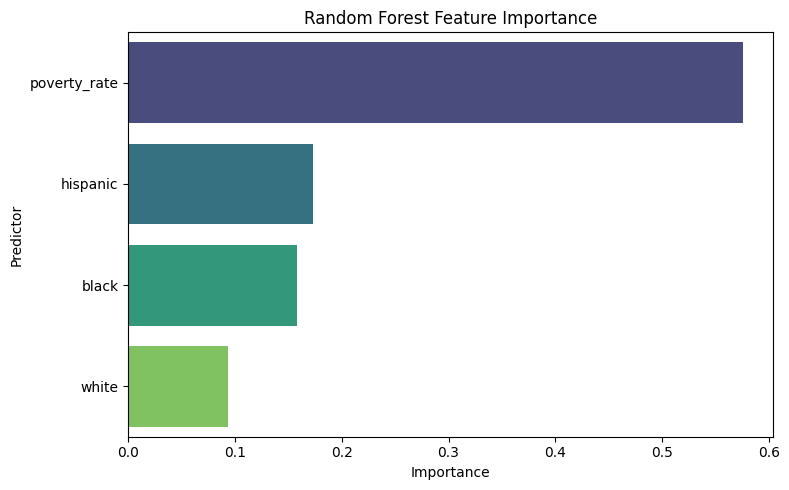

,Feature,Importance
0,poverty_rate,0.575489
3,hispanic,0.173348
1,black,0.157784
2,white,0.093379


In [4]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Predictor")
plt.tight_layout()
plt.show()

importance_df

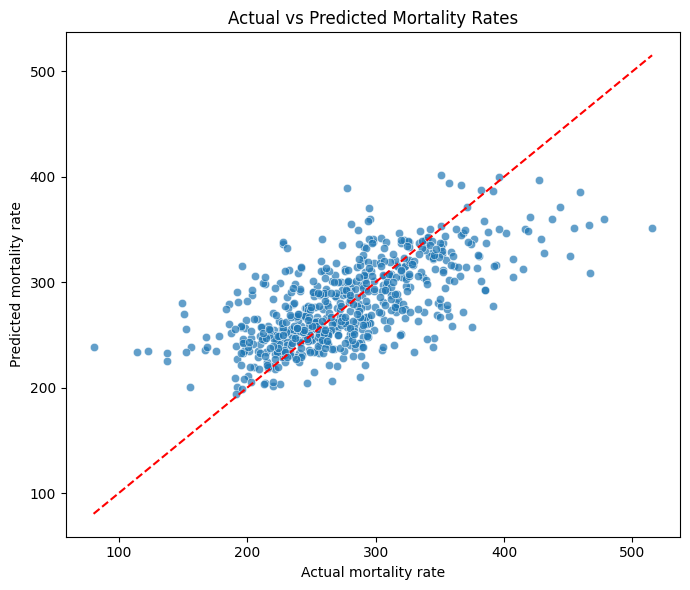

In [5]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], color="red", linestyle="--")
plt.title("Actual vs Predicted Mortality Rates")
plt.xlabel("Actual mortality rate")
plt.ylabel("Predicted mortality rate")
plt.tight_layout()
plt.show()

### 4.3 Interpretation

The hypothesis tests provide formal evidence for the relationships observed in the EDA. When the adjusted p-values are below 0.05, these relationships can be considered statistically significant even after correcting for multiple comparisons, suggesting that they are unlikely to be due to random chance.

The Random Forest model, on the other hand, focuses on prediction. It evaluates whether poverty and ethnic composition together can explain variation in cardiovascular mortality rates. Model performance is measured using MAE, RMSE, and R-squared. Lower MAE and RMSE values indicate better predictive accuracy, while a higher R-squared value shows that the model explains a larger portion of the variation in mortality.

Feature importance results help us understand which variables drive the model’s predictions. If poverty rate appears as the most important feature, this reinforces the idea that socioeconomic disadvantage plays a key role in mortality outcomes. However, if ethnic composition variables are also important, this suggests that mortality differences are not explained by poverty alone, but are also related to broader demographic and structural factors.

## Additional Baseline Model Comparison for Final Submission

Based on the TA feedback, I added a baseline model comparison for the final submission. Since the target variable, cardiovascular mortality rate, is continuous, I used regression-based baseline models instead of Logistic Regression. Linear Regression and Decision Tree Regressor were compared with the existing Random Forest Regressor.

The purpose of this comparison is to check whether the Random Forest model provides a meaningful improvement over simpler models.

In [6]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=5,
        min_samples_leaf=10,
        random_state=42
    ),
    "Random Forest Regressor": rf_model
}

comparison_results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    comparison_results.append({
        "Model": model_name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R-squared": round(r2, 3)
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Model,MAE,RMSE,R-squared
0,Linear Regression,34.568,45.914,0.402
1,Decision Tree Regressor,35.917,47.183,0.368
2,Random Forest Regressor,33.130,43.917,0.453


### Interpretation of Baseline Model Comparison

The comparison shows that the Random Forest Regressor performed best among the tested models. It achieved the lowest MAE and RMSE values and the highest R-squared score.

Linear Regression also performed reasonably well, with an R-squared value of 0.402. This suggests that part of the relationship between poverty, demographic variables, and cardiovascular mortality can be captured by a simple linear model. However, Random Forest improved the R-squared value to 0.453, suggesting that a more flexible model can capture additional patterns.

The Decision Tree Regressor performed worse than both Linear Regression and Random Forest. This may be because a single decision tree is less stable and less effective than an ensemble model.

Overall, Random Forest was the best predictive model in this project, even if it is not enough to fully explain cardiovascular mortality differences across counties. The reason why it is the best model is our research questions has different instances such as demography an poverty level. Random Forest Regressor combines the predictions of multiple decision (multiple features we have)trees by averaging their outputs.